# 한강공원 주차장 혼잡도 예측 — Optuna 튜닝 + Voting/Stacking 앙상블

5회차 보강판. 두 강의 자료에서 배운 패턴을 그대로 적용합니다.

**자전거 수요예측 실습에서 가져온 패턴**
- 타깃 로그 변환 (`np.log1p` / `np.expm1`)
- `TimeSeriesSplit` 교차검증 (시간 순서 유지)
- `make_scorer()`로 만든 커스텀 RMSLE 스코어러
- 선형모델 여러 종 비교 → 트리 앙상블 여러 종 비교 → 최종 비교 흐름

**캐글 주택가격 회귀실습에서 가져온 패턴**
- 왜도(Skewness) 분석 후 치우친 피처 자동 로그 변환
- 산점도 기반 이상치(Outlier) 탐지 및 제거
- `GridSearchCV`로 Ridge/Lasso 최적 alpha 탐색
- K-Fold 기반 수동 OOF(Out-Of-Fold) 스태킹

**이번 노트북에서 추가하는 것**
- Optuna로 LightGBM / XGBoost 하이퍼파라미터 자동 탐색
- VotingRegressor(가중 평균)와 StackingRegressor(메타모델) 정면 비교
- sklearn StackingRegressor vs 수동 OOF 스태킹 비교
- 어떤 방식이 이 데이터에 더 잘 맞는지 Test set 성능으로 결론

실행 순서: 위에서 아래로 순서대로 셀을 실행하세요 (Shift + Enter)

In [1]:
pip install pandas scikit-learn joblib matplotlib seaborn sqlalchemy pymysql python-dotenv optuna lightgbm xgboost scipy mlflow

Note: you may need to restart the kernel to use updated packages.


## 1. 환경 설정

```bash
pip install pandas scikit-learn joblib matplotlib seaborn sqlalchemy pymysql python-dotenv optuna lightgbm xgboost scipy
```

In [2]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from scipy.stats import skew

from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    VotingRegressor,
    StackingRegressor,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna

import mlflow            # 실험 기록
import mlflow.sklearn

plt.rcParams["axes.unicode_minus"] = False
# plt.rcParams["font.family"] = "AppleGothic"   # Mac
# plt.rcParams["font.family"] = "Malgun Gothic" # Windows

SEED = 42
np.random.seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 2. DB 연결 + 데이터 조회

기존 5회차와 동일한 SQL입니다.

In [3]:
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

DATABASE_URL = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    print("DB 연결 성공" if conn.execute(text("SELECT 1")).scalar() == 1 else "DB 연결 실패")

DB 연결 성공


In [4]:
sql = """
    SELECT
        d.lot_id,
        i.capacity,
        MONTH(d.use_date)                          AS month,
        DAYOFWEEK(d.use_date)                      AS day_of_week,
        CASE WHEN DAYOFWEEK(d.use_date) IN (1,7)
             THEN 1 ELSE 0 END                     AS is_weekend,
        WEEKOFYEAR(d.use_date)                     AS week_of_year,
        COALESCE(h.holiday_date IS NOT NULL, 0)    AS is_holiday,
        d.use_date,
        d.daily_count                              AS daily_count,   -- ★ 예측 타깃(일 이용대수)
        ROUND(d.daily_count / i.capacity * 100, 2) AS turnover_pct   -- 참고용 회전율
    FROM parking_daily d
    INNER JOIN parking_info i ON d.lot_id   = i.id
    LEFT  JOIN holidays     h ON d.use_date = h.holiday_date
    WHERE d.daily_count > 0
      AND i.capacity    > 0
    ORDER BY d.use_date, d.lot_id
"""

df = pd.read_sql(text(sql), engine)
print(f"로드 완료: {len(df):,}행 x {len(df.columns)}열")

# ── 이상치 처리 방침 변경 ────────────────────────────────────
# daily_count는 '하루 누적 이용대수(회전 포함)'라 면수를 넘는 게 정상(약 80%).
# 예전의 '혼잡도>100% 제거'는 데이터의 80%를 버리므로 삭제한다.
# daily_count<=0 등 명백한 오류만 SQL WHERE에서 이미 걸렀다.
print(f"전체 데이터: {len(df):,}행 (100% 초과 제거하지 않음)")
print(f"daily_count 범위: {df['daily_count'].min():,} ~ {df['daily_count'].max():,}대")
df.head()

로드 완료: 21,869행 x 10열
전체 데이터: 21,869행 (100% 초과 제거하지 않음)
daily_count 범위: 1 ~ 15,521대


,lot_id,capacity,month,day_of_week,is_weekend,week_of_year,is_holiday,use_date,daily_count,turnover_pct
0,2,1782,1,3,0,3,0,2020-01-14,2,0.11
1,2,1782,1,4,0,3,0,2020-01-15,114,6.40
2,7,99,1,4,0,3,0,2020-01-15,12,12.12
3,2,1782,1,5,0,3,0,2020-01-16,873,48.99
4,7,99,1,5,0,3,0,2020-01-16,28,28.28


## 3. 산점도 기반 이상치 탐지 (캐글 주택가격 패턴)

캐글 주택가격 실습에서 `GrLivArea`(면적)가 큰데 `SalePrice`(가격)가 비정상적으로 낮은 점을 산점도로 찾아서 제거한 것과 같은 방식입니다.

한강 데이터에서는 `capacity`(총 주차면수)가 큰 주차장인데 `occupancy_pct`(혼잡도)가 비정상적으로 튀는 행이 있는지 확인합니다.

/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/4087181095.py:6: UserWarning: 

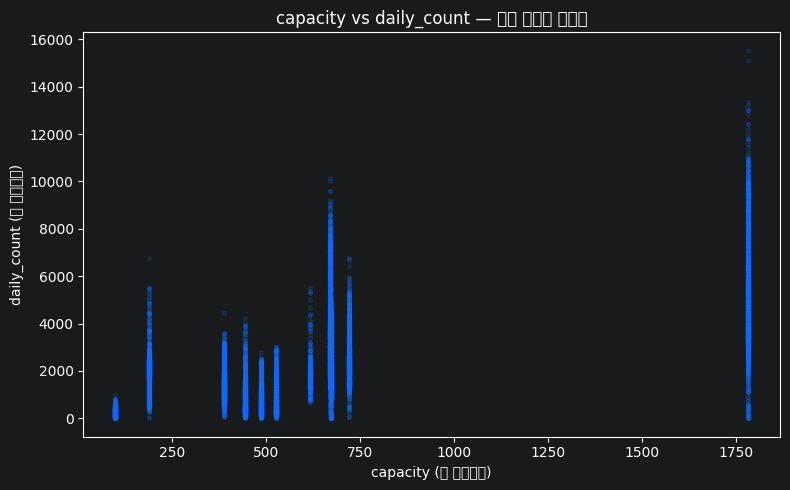

lot_id
7       99
10     190
11     389
9      445
8      488
5      526
6      618
3      669
1      674
4      722
2     1782
Name: capacity, dtype: int64


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df["capacity"], df["daily_count"], alpha=0.15, s=8, color="#0d6efd")
plt.xlabel("capacity (총 주차면수)")
plt.ylabel("daily_count (일 이용대수)")
plt.title("capacity vs daily_count — 분포 확인용 산점도")
plt.tight_layout()
plt.show()

# 주차장별 규모(capacity) 확인
print(df.groupby("lot_id")["capacity"].first().sort_values())

In [6]:
# ── 이상치 점검 (daily_count 기준) ──────────────────────────
# 타깃이 daily_count로 바뀌었으므로, 예전의 'occupancy_pct>95%' 기준은
# 더 이상 이상치 기준이 될 수 없다(대부분이 100%를 넘기 때문).
# 여기서는 명백한 입력 오류만 최소한으로 점검한다.
#   예) 이용대수가 비상식적으로 큰 극단치(상위 0.1% 초과) 정도만 확인.
q999 = df["daily_count"].quantile(0.999)
extreme = df[df["daily_count"] > q999]
print(f"상위 0.1% 초과(daily_count > {q999:,.0f}) 행: {len(extreme)}개")
print("→ 데이터 특성상 정상 범위로 보고 제거하지 않습니다. (필요 시 여기서 조정)")
print(f"최종 데이터: {len(df):,}행")

상위 0.1% 초과(daily_count > 10,967) 행: 22개
→ 데이터 특성상 정상 범위로 보고 제거하지 않습니다. (필요 시 여기서 조정)
최종 데이터: 21,869행


## 4. 수치형 피처 왜도(Skewness) 분석 (캐글 주택가격 패턴)

타깃(`occupancy_pct`)만 로그 변환했는데, 입력 피처들도 분포가 한쪽으로 치우쳐 있으면(왜도가 크면) 로그 변환으로 모델 학습이 더 안정적으로 됩니다.

`lot_id`, `is_weekend`, `is_holiday`처럼 범주형 성격의 숫자는 왜도 분석 대상에서 제외하고, 연속적인 값(`capacity`, `week_of_year`)만 확인합니다.

In [7]:
# 연속형 수치 피처만 왜도 분석 대상으로 선정
# (lot_id, day_of_week, is_weekend, is_holiday는 범주형 성격이라 로그 변환 대상에서 제외)
continuous_features = ["capacity", "week_of_year"]

skew_features = df[continuous_features].apply(lambda x: skew(x))
print("왜도(Skewness) 값:")
print(skew_features.sort_values(ascending=False))
print()
print("왜도 절댓값이 1을 넘으면 분포가 많이 치우친 것으로 봅니다.")
skew_features_top = skew_features[skew_features.abs() > 1]
print(f"\n왜도 > 1인 피처: {list(skew_features_top.index) if len(skew_features_top) > 0 else '없음'}")

왜도(Skewness) 값:
capacity        1.704335
week_of_year    0.109247
dtype: float64

왜도 절댓값이 1을 넘으면 분포가 많이 치우친 것으로 봅니다.

왜도 > 1인 피처: ['capacity']


왜도가 낮으면(보통 |왜도| < 1) 추가 로그 변환은 생략합니다. 한강 데이터의 `capacity`, `week_of_year`는 원래 분포가 고르게 퍼져 있어서 캐글 주택가격의 `GrLivArea`만큼 치우치지 않는 경우가 많습니다. 위 셀의 출력값을 직접 확인하고, 왜도가 1을 넘는 피처가 있다면 아래 셀의 주석을 해제해서 로그 변환을 적용하세요.

In [8]:
# 왜도가 높은 피처가 있을 경우에만 사용하는 셀입니다.
# 위 셀의 출력에서 skew_features_top이 비어있지 않다면 아래 줄의 주석을 해제하세요.

# for col in skew_features_top.index:
#     df[col] = np.log1p(df[col])
#     print(f"{col} 로그 변환 적용 완료")

print("왜도 분석 완료 — 출력값을 보고 필요 시 위 코드 주석을 해제해 로그 변환을 적용하세요.")

왜도 분석 완료 — 출력값을 보고 필요 시 위 코드 주석을 해제해 로그 변환을 적용하세요.


## 5. 평가 지표 함수 정의

자전거 수요예측 실습에서 그대로 가져온 패턴입니다. RMSLE는 상대 오차를 측정하므로 혼잡도(%)처럼 0~100 범위인 값에 잘 맞습니다.

In [9]:
from datetime import datetime

def rmsle(y, pred):
    """로그 변환 후 RMSE. 작은 값과 큰 값의 상대 오차를 동등하게 평가합니다."""
    log_y    = np.log1p(y)
    log_pred = np.log1p(np.maximum(pred, 0))  # 음수 예측 방지
    return np.sqrt(np.mean((log_y - log_pred) ** 2))


def rmse(y, pred):
    return np.sqrt(mean_squared_error(y, pred))


def evaluate_regr(y, pred, name="", model=None, log_to_mlflow=True):
    """RMSLE / RMSE / MAE 세 지표를 출력하고, MLflow에도 기록합니다.

    매개변수:
      y, pred        : 실제값 / 예측값
      name           : Run 이름(모델 이름). 비어 있으면 MLflow 기록을 건너뜁니다.
      model          : 모델 객체를 넘기면 하이퍼파라미터(get_params)도 함께 기록합니다.
      log_to_mlflow  : False면 MLflow 기록 없이 출력만 합니다(중간 점검용).
    """
    rmsle_val = rmsle(y, pred)
    rmse_val  = rmse(y, pred)
    mae_val   = mean_absolute_error(y, pred)
    label = f"[{name}] " if name else ""
    print(f"{label}RMSLE: {rmsle_val:.4f}, RMSE: {rmse_val:.3f}, MAE: {mae_val:.3f}")

    # ═══════════════════════════════════════════════════════════
    # MLflow 기록
    # ───────────────────────────────────────────────────────────
    # name이 있고 log_to_mlflow=True일 때만, 이 평가를 하나의 Run으로 남긴다.
    #   · start_run(run_name=...) : 이 with 블록이 곧 하나의 실험(Run).
    #   · log_param   : '설정값' 하나 기록(모델 이름)
    #   · log_params  : model.get_params()를 통째로 기록 → 모든 하이퍼파라미터
    #                   (learning_rate, max_depth, alpha 등)를 한 번에 남긴다.
    #                   UI Parameters 열에서 모델별로 나란히 비교 가능.
    #   · set_tag     : run_date 태그로 '언제 실행했는지'(초까지) 기록 →
    #                   UI에서 tags.run_date로 날짜/시간별 조회.
    #   · log_metric  : 성능 지표(RMSLE/RMSE/MAE) → 정렬·차트 비교.
    # ※ 모델 파일(log_model)은 남기지 않는다(비교 목적). 배포용 저장은
    #    아래 pkl 저장 셀에서 joblib으로 따로 한다.
    # ═══════════════════════════════════════════════════════════
    if log_to_mlflow and name:
        with mlflow.start_run(run_name=name):
            mlflow.log_param("model", name)                    # 모델 이름
            if model is not None:
                mlflow.log_params(model.get_params())          # 하이퍼파라미터 전체
            mlflow.set_tag("run_date", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
            mlflow.log_metric("rmsle", rmsle_val)
            mlflow.log_metric("rmse",  rmse_val)
            mlflow.log_metric("mae",   mae_val)

    return {"name": name, "rmsle": rmsle_val, "rmse": rmse_val, "mae": mae_val}

### MLflow 실험 설정

이후 evaluate_regr로 평가하는 모든 모델이 이 실험에 기록됩니다. (SQLite 백엔드)

In [10]:
# SQLite DB에 실험 기록(set_experiment보다 먼저).
#   UI 실행: mlflow ui --backend-store-uri sqlite:///mlflow.db
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("hangang_parking_ensemble")
print("MLflow 실험 설정 완료:", mlflow.get_tracking_uri())

2026/07/07 17:48:26 INFO mlflow.tracking.fluent: Experiment with name 'hangang_parking_ensemble' does not exist. Creating a new experiment.


MLflow 실험 설정 완료: sqlite:///mlflow.db


## 6. 피처/타깃 분리 + 시간순 Train/Test 분할

`predict.py`의 X 순서와 반드시 일치해야 하는 `FEATURE_COLUMNS`를 그대로 사용합니다.

시간 순서를 유지하기 위해 무작위 분할(`train_test_split`) 대신 날짜 기준 80:20 분할을 사용합니다 (자전거 수요예측 Step 1과 동일한 방식).

In [11]:
FEATURE_COLUMNS = [
    "lot_id", "capacity", "month", "day_of_week",
    "is_weekend", "week_of_year", "is_holiday",
]
TARGET_COLUMN = "daily_count"   # ★ 혼잡도(%)가 아니라 '일 이용대수'를 예측

df_sorted = df.sort_values("use_date").reset_index(drop=True)

X_features = df_sorted[FEATURE_COLUMNS]
y_target   = df_sorted[TARGET_COLUMN]

split_idx = int(len(X_features) * 0.8)

X_train_full = X_features.iloc[:split_idx]
X_test       = X_features.iloc[split_idx:]
y_train_full = y_target.iloc[:split_idx]
y_test       = y_target.iloc[split_idx:]

print(f"전체 데이터  : {len(X_features):,}행  (타깃: {TARGET_COLUMN})")
print(f"훈련셋 (80%) : {len(X_train_full):,}행")
print(f"테스트셋(20%): {len(X_test):,}행")

전체 데이터  : 21,869행  (타깃: daily_count)
훈련셋 (80%) : 17,495행
테스트셋(20%): 4,374행


### 타깃 로그 변환

자전거 수요예측과 동일하게 `np.log1p()`로 타깃을 변환해서 학습하고, 평가할 때 `np.expm1()`으로 되돌립니다.

/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: UserWarning: Glyph 54872 (\N{HANGUL SYLLABLE HWAN}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/2266509672.py:16: User

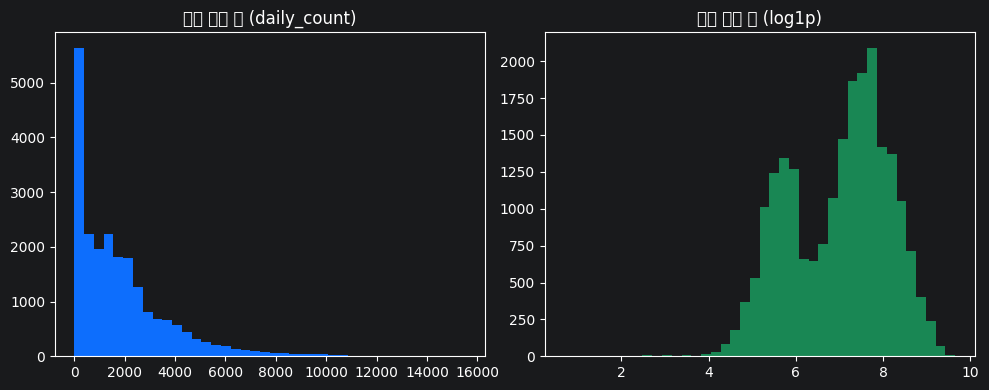

In [12]:
# daily_count는 값이 크고 오른쪽으로 치우친 분포라 로그 변환이 특히 잘 맞는다.
# 로그 학습 후 예측은 np.expm1로 되돌린다(모델들이 log 타깃으로 학습).
y_target_log     = np.log1p(y_target)
y_train_log_full = y_target_log.iloc[:split_idx]
y_test_log       = y_target_log.iloc[split_idx:]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_target, bins=40, color="#0d6efd")
plt.title("로그 변환 전 (daily_count)")

plt.subplot(1, 2, 2)
plt.hist(y_target_log, bins=40, color="#198754")
plt.title("로그 변환 후 (log1p)")

plt.tight_layout()
plt.show()

## 7. RMSLE 커스텀 스코어러

`cross_val_score()`에는 RMSLE가 기본 제공되지 않으므로 `make_scorer()`로 직접 만듭니다. 자전거 수요예측의 `rmsle_log_target()` 패턴 그대로입니다.

In [13]:
def rmsle_log_target(y_true_log, y_pred_log):
    """로그 스케일로 이미 변환된 타깃끼리 비교하는 RMSLE."""
    y_pred_clipped = np.maximum(y_pred_log, 0)
    return np.sqrt(np.mean((y_true_log - y_pred_clipped) ** 2))


rmsle_scorer = make_scorer(rmsle_log_target, greater_is_better=False)

tscv = TimeSeriesSplit(n_splits=5)
print("TimeSeriesSplit(n_splits=5) 준비 완료")

TimeSeriesSplit(n_splits=5) 준비 완료


## 8. 베이스라인 — 선형모델 3종 비교

자전거 수요예측 Step 4와 동일한 패턴: LinearRegression / Ridge / Lasso를 TimeSeriesSplit 교차검증으로 비교합니다.

In [14]:
def get_model_predict(model, X_train, X_test, y_train, y_test, is_expm1=False, name=None):
    """모델 학습 -> 예측 -> 평가까지 한 번에 처리하는 헬퍼 함수."""
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if is_expm1:
        y_test = np.expm1(y_test)
        pred   = np.expm1(np.maximum(pred, 0))
    label = name or model.__class__.__name__
    # model=model 을 넘겨 하이퍼파라미터까지 MLflow에 기록
    return evaluate_regr(y_test, pred, label, model=model)


lr_reg    = LinearRegression()
ridge_reg = Ridge(alpha=10)
lasso_reg = Lasso(alpha=0.01)

print("TimeSeriesSplit 교차검증 결과 - 선형 모델 3종 (기본 alpha)")
print(f'{"모델":<20} {"RMSLE 평균":>12} {"RMSLE std":>10}')
for model in [lr_reg, ridge_reg, lasso_reg]:
    cv_rmsle = -1 * cross_val_score(
        model, X_train_full, y_train_log_full,
        cv=tscv, scoring=rmsle_scorer,
    )
    print(f"  {model.__class__.__name__:<18} {cv_rmsle.mean():>12.4f} {cv_rmsle.std():>10.4f}")

print()
print("최종 테스트셋 평가 - 선형 모델 3종 (기본 alpha)")
linear_results = []
for model in [lr_reg, ridge_reg, lasso_reg]:
    linear_results.append(
        get_model_predict(model, X_train_full, X_test, y_train_log_full, y_test_log, is_expm1=True)
    )

TimeSeriesSplit 교차검증 결과 - 선형 모델 3종 (기본 alpha)
모델                       RMSLE 평균  RMSLE std
  LinearRegression         0.9126     0.0669
  Ridge                    0.9123     0.0669
  Lasso                    0.9124     0.0670

최종 테스트셋 평가 - 선형 모델 3종 (기본 alpha)
[LinearRegression] RMSLE: 0.8768, RMSE: 1523.387, MAE: 1117.759
[Ridge] RMSLE: 0.8767, RMSE: 1523.409, MAE: 1117.744
[Lasso] RMSLE: 0.8721, RMSE: 1525.168, MAE: 1117.574


## 9. GridSearchCV로 Ridge/Lasso 최적 alpha 탐색 (캐글 주택가격 패턴)

Optuna는 트리 모델(LightGBM, XGBoost)처럼 탐색 공간이 넓고 복잡할 때 유리합니다. Ridge/Lasso는 튜닝할 하이퍼파라미터가 `alpha` 하나뿐이라 격자 탐색(GridSearchCV)이 더 빠르고 직관적입니다.

In [15]:
ridge_params = {"alpha": [0.05, 0.1, 1, 5, 8, 10, 12, 15, 20]}
lasso_params = {"alpha": [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]}


def print_best_params(model, params):
    """GridSearchCV로 최적 alpha를 찾고, 그 alpha로 학습된 모델을 반환합니다."""
    grid_model = GridSearchCV(
        model, param_grid=params,
        scoring=rmsle_scorer, cv=tscv,
    )
    grid_model.fit(X_train_full, y_train_log_full)
    best_rmsle = -1 * grid_model.best_score_
    print(f"{model.__class__.__name__} 5-CV 최적 RMSLE: {best_rmsle:.4f}  "
          f"최적 하이퍼파라미터: {grid_model.best_params_}")
    return grid_model.best_estimator_


print("GridSearchCV로 Ridge/Lasso 최적 alpha 탐색 중...")
best_ridge = print_best_params(ridge_reg, ridge_params)
best_lasso = print_best_params(lasso_reg, lasso_params)

GridSearchCV로 Ridge/Lasso 최적 alpha 탐색 중...
Ridge 5-CV 최적 RMSLE: 0.9122  최적 하이퍼파라미터: {'alpha': 20}
Lasso 5-CV 최적 RMSLE: 0.9121  최적 하이퍼파라미터: {'alpha': 0.001}


In [16]:
print("최종 테스트셋 평가 - GridSearch로 튜닝된 Ridge/Lasso")
tuned_linear_results = []
for model in [best_ridge, best_lasso]:
    tuned_linear_results.append(
        get_model_predict(
            model, X_train_full, X_test, y_train_log_full, y_test_log,
            is_expm1=True, name=f"{model.__class__.__name__}(GridSearch)"
        )
    )

최종 테스트셋 평가 - GridSearch로 튜닝된 Ridge/Lasso
[Ridge(GridSearch)] RMSLE: 0.8766, RMSE: 1523.433, MAE: 1117.732
[Lasso(GridSearch)] RMSLE: 0.8760, RMSE: 1523.260, MAE: 1117.528


## 10. Optuna로 LightGBM / XGBoost 하이퍼파라미터 튜닝

자전거 수요예측에서 비교만 했던 트리 앙상블(RandomForest, GBM, XGBoost, LightGBM)을 한 단계 더 발전시켜서, Optuna로 LightGBM과 XGBoost의 하이퍼파라미터를 자동 탐색합니다.

**Optuna 동작 원리**: Trial마다 다른 하이퍼파라미터 조합으로 TimeSeriesSplit 교차검증 RMSLE를 측정하고, TPE(Tree-structured Parzen Estimator) 알고리즘이 더 좋은 영역을 점점 더 탐색합니다.

**왜 Ridge/Lasso는 GridSearch, LightGBM/XGBoost는 Optuna인가**: 파라미터가 1개면 격자 탐색으로 전부 다 시도해도 빠릅니다. 파라미터가 7~9개로 늘어나면 격자 탐색은 조합 수가 기하급수적으로 늘어나 비효율적이라, Optuna처럼 똑똑하게 탐색 범위를 좁혀가는 방법이 유리합니다.

In [17]:
def lgbm_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate"    : trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth"        : trial.suggest_int("max_depth", 3, 10),
        "num_leaves"       : trial.suggest_int("num_leaves", 16, 128),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample"        : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
        "random_state"     : SEED,
        "n_jobs"           : -1,
        "verbose"          : -1,
    }
    model = LGBMRegressor(**params)
    cv_rmsle = -1 * cross_val_score(
        model, X_train_full, y_train_log_full,
        cv=tscv, scoring=rmsle_scorer,
    )
    return cv_rmsle.mean()


print("LightGBM Optuna 튜닝 시작 (50 trials)...")
lgbm_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
lgbm_study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)

print(f"\n최적 RMSLE(CV 평균): {lgbm_study.best_value:.4f}")
print(f"최적 파라미터: {lgbm_study.best_params}")

LightGBM Optuna 튜닝 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


최적 RMSLE(CV 평균): 0.4959
최적 파라미터: {'n_estimators': 250, 'learning_rate': 0.012229728757262196, 'max_depth': 5, 'num_leaves': 26, 'min_child_samples': 54, 'subsample': 0.7697847388383272, 'colsample_bytree': 0.7081409645266099, 'reg_alpha': 4.432034496229257e-06, 'reg_lambda': 8.104827941476208e-05}


In [18]:
def xgb_objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 1000),
        "learning_rate"   : trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 15),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-8, 5.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-8, 5.0, log=True),
        "random_state"    : SEED,
        "n_jobs"          : -1,
        "verbosity"       : 0,
        "tree_method"     : "hist",
    }
    model = XGBRegressor(**params)
    cv_rmsle = -1 * cross_val_score(
        model, X_train_full, y_train_log_full,
        cv=tscv, scoring=rmsle_scorer,
    )
    return cv_rmsle.mean()


print("XGBoost Optuna 튜닝 시작 (50 trials)...")
xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n최적 RMSLE(CV 평균): {xgb_study.best_value:.4f}")
print(f"최적 파라미터: {xgb_study.best_params}")

XGBoost Optuna 튜닝 시작 (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


최적 RMSLE(CV 평균): 0.5054
최적 파라미터: {'n_estimators': 353, 'learning_rate': 0.009196007537595136, 'max_depth': 5, 'min_child_weight': 14, 'subsample': 0.6751674452819894, 'colsample_bytree': 0.7561436392188481, 'reg_alpha': 2.8441925018821704e-06, 'reg_lambda': 7.907634836257878e-06}


### Optuna 탐색 과정 시각화

trial이 거듭될수록 RMSLE가 어떻게 낮아지는지 확인합니다.

/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3222749847.py:13: UserWarn

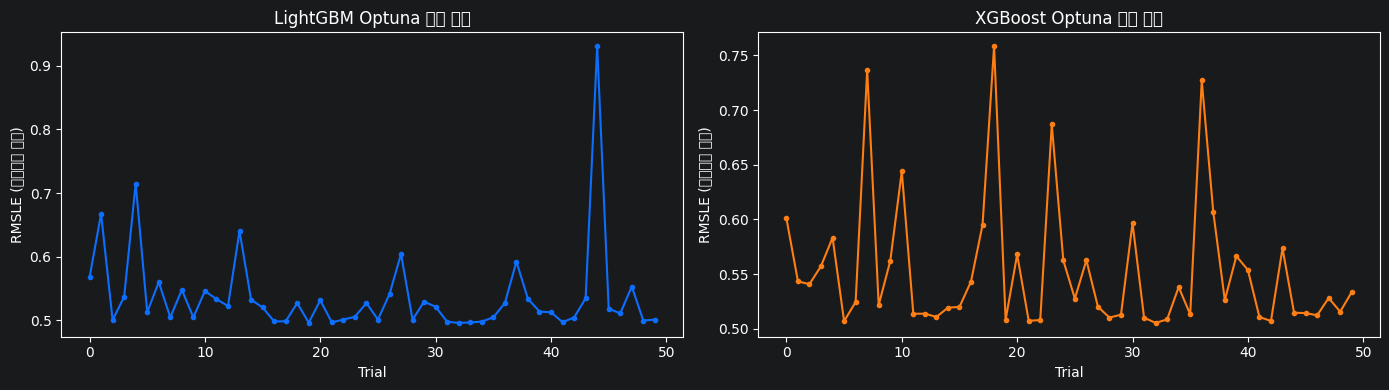

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lgbm_study.trials_dataframe()["value"], color="#0d6efd", marker="o", markersize=3)
axes[0].set_title("LightGBM Optuna 탐색 과정")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("RMSLE (낮을수록 좋음)")

axes[1].plot(xgb_study.trials_dataframe()["value"], color="#fd7e14", marker="o", markersize=3)
axes[1].set_title("XGBoost Optuna 탐색 과정")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("RMSLE (낮을수록 좋음)")

plt.tight_layout()
plt.show()

## 11. 튜닝된 단일 모델 테스트셋 평가

Optuna가 찾은 최적 파라미터로 모델을 만들어 최종 테스트셋에서 평가합니다. (이 단계가 이후 앙상블의 베이스 모델이 됩니다.)

In [20]:
lgbm_best = LGBMRegressor(**lgbm_study.best_params, random_state=SEED, n_jobs=-1, verbose=-1)
xgb_best  = XGBRegressor(**xgb_study.best_params, random_state=SEED, n_jobs=-1, verbosity=0, tree_method="hist")

print("최종 테스트셋 평가 - 튜닝된 단일 모델")
single_results = []
single_results.append(
    get_model_predict(lgbm_best, X_train_full, X_test, y_train_log_full, y_test_log, is_expm1=True, name="LightGBM(tuned)")
)
single_results.append(
    get_model_predict(xgb_best, X_train_full, X_test, y_train_log_full, y_test_log, is_expm1=True, name="XGBoost(tuned)")
)

최종 테스트셋 평가 - 튜닝된 단일 모델
[LightGBM(tuned)] RMSLE: 0.6856, RMSE: 1041.100, MAE: 707.264
[XGBoost(tuned)] RMSLE: 0.6865, RMSE: 1019.730, MAE: 693.170


## 12. 앙상블 ① VotingRegressor

여러 모델의 예측값을 평균(또는 가중평균)해서 합치는 방식입니다. 튜닝된 LightGBM, XGBoost에 RandomForest를 더해 3개 모델을 voting으로 묶습니다.

In [21]:
rf_reg = RandomForestRegressor(
    n_estimators=300, max_depth=12, random_state=SEED, n_jobs=-1,
)

voting_reg = VotingRegressor(
    estimators=[
        ("lgbm", lgbm_best),
        ("xgb",  xgb_best),
        ("rf",   rf_reg),
    ],
    weights=[2, 2, 1],  # 트리 부스팅 두 모델에 더 높은 가중치
)

voting_result = get_model_predict(
    voting_reg, X_train_full, X_test, y_train_log_full, y_test_log,
    is_expm1=True, name="VotingRegressor",
)

[VotingRegressor] RMSLE: 0.6882, RMSE: 1009.030, MAE: 685.803


## 13. 앙상블 ② StackingRegressor (sklearn 내장)

베이스 모델들의 예측값을 다시 메타모델(최종 학습기)에 넣어서 학습하는 방식입니다. 베이스 모델은 voting과 동일하게 구성하고, 메타모델은 Ridge(선형 모델)를 사용합니다.

In [22]:
stacking_reg = StackingRegressor(
    estimators=[
        ("lgbm", lgbm_best),
        ("xgb",  xgb_best),
        ("rf",   rf_reg),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,  # 메타모델 학습용 데이터도 시간순 분할 유지
)

stacking_result = get_model_predict(
    stacking_reg, X_train_full, X_test, y_train_log_full, y_test_log,
    is_expm1=True, name="StackingRegressor(sklearn)",
)

[StackingRegressor(sklearn)] RMSLE: 0.7029, RMSE: 969.410, MAE: 661.406


## 14. 앙상블 ③ 수동 OOF 스태킹 (캐글 주택가격 패턴)

캐글 주택가격 실습에서 쓴 방식입니다. sklearn `StackingRegressor`는 내부적으로 비슷한 일을 하지만, 폴드를 직접 제어하고 각 베이스 모델의 메타데이터를 눈으로 확인할 수 있다는 차이가 있습니다.

**핵심 아이디어 (OOF: Out-Of-Fold)**: 베이스 모델이 학습에 쓰지 않은 폴드(검증 폴드)만 예측해서 메타모델 학습용 데이터를 만듭니다. 이렇게 하면 베이스 모델이 "이미 본 데이터"로 메타모델을 학습시키는 데이터 누수를 막을 수 있습니다.

```
학습 데이터를 5개 폴드로 분할
  Fold 1: [검증][학습][학습][학습][학습] -> 검증 부분만 예측 -> 메타 학습용 데이터 1/5 완성
  Fold 2: [학습][검증][학습][학습][학습] -> 검증 부분만 예측 -> 메타 학습용 데이터 2/5 완성
  ...
  5개 폴드 전부 돌면 전체 학습 데이터에 대한 OOF 예측이 완성됨
```

In [23]:
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds=5):
    """
    K-Fold OOF 방식으로 메타모델 학습용 데이터를 만듭니다.

    Returns:
        meta_train_fold_pred: (학습 데이터 수, 1) - 각 행은 해당 행이 검증 폴드였을 때의 예측값
        meta_test_pred_mean : (테스트 데이터 수, 1) - 폴드별 테스트 예측을 평균한 값
    """
    # shuffle=False: 시계열 데이터이므로 순서를 섞지 않습니다.
    kf = KFold(n_splits=n_folds, shuffle=False)

    meta_train_fold_pred = np.zeros((X_train_n.shape[0], 1))
    meta_test_pred       = np.zeros((X_test_n.shape[0], n_folds))

    print(f"{model.__class__.__name__} OOF 스태킹 시작")

    for folder_cnt, (train_idx, valid_idx) in enumerate(kf.split(X_train_n)):
        X_tr = X_train_n[train_idx]
        y_tr = y_train_n[train_idx]
        X_va = X_train_n[valid_idx]

        model.fit(X_tr, y_tr)
        # 검증 폴드만 예측 -> 메타 학습 데이터의 해당 위치에 저장 (데이터 누수 방지)
        meta_train_fold_pred[valid_idx, :] = model.predict(X_va).reshape(-1, 1)
        # 전체 테스트셋도 매 폴드마다 예측 -> 나중에 5개 폴드 결과를 평균
        meta_test_pred[:, folder_cnt] = model.predict(X_test_n)

    meta_test_pred_mean = np.mean(meta_test_pred, axis=1).reshape(-1, 1)
    return meta_train_fold_pred, meta_test_pred_mean


# pandas DataFrame -> numpy ndarray 변환 (인덱싱 위치 기반 접근을 위해 필요)
X_train_n = X_train_full.values
X_test_n  = X_test.values
y_train_n = y_train_log_full.values

# 베이스 모델 3개로 OOF 메타데이터 생성 (LightGBM, XGBoost, RandomForest)
lgbm_tr, lgbm_ts = get_stacking_base_datasets(lgbm_best, X_train_n, y_train_n, X_test_n, n_folds=5)
xgb_tr,  xgb_ts  = get_stacking_base_datasets(xgb_best,  X_train_n, y_train_n, X_test_n, n_folds=5)
rf_tr,   rf_ts   = get_stacking_base_datasets(rf_reg,    X_train_n, y_train_n, X_test_n, n_folds=5)

LGBMRegressor OOF 스태킹 시작


/Users/home/hangang_parking/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/home/hangang_parking/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/home/hangang_parking/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/home/hangang_parking/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/home/hangang_parking/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but L

XGBRegressor OOF 스태킹 시작
RandomForestRegressor OOF 스태킹 시작


In [24]:
# 메타 모델 입력 데이터 구성: 베이스 모델 3개의 예측값만으로 (N, 3) 행렬을 만듭니다.
Stack_final_X_train = np.concatenate((lgbm_tr, xgb_tr, rf_tr), axis=1)
Stack_final_X_test  = np.concatenate((lgbm_ts, xgb_ts, rf_ts), axis=1)

print(f"메타모델 학습 데이터 shape: {Stack_final_X_train.shape}  (행 수, 베이스모델 3개)")

meta_model = Ridge(alpha=1.0)
meta_model.fit(Stack_final_X_train, y_train_log_full)

pred_log = meta_model.predict(Stack_final_X_test)
oof_stacking_result = evaluate_regr(
    np.expm1(y_test_log),
    np.expm1(np.maximum(pred_log, 0)),
    name="OOF_Stacking(수동)",
    model=meta_model,   # 메타모델(Ridge) 하이퍼파라미터도 기록
)

메타모델 학습 데이터 shape: (17495, 3)  (행 수, 베이스모델 3개)
[OOF_Stacking(수동)] RMSLE: 0.7052, RMSE: 977.770, MAE: 672.859


## 15. 전체 결과 비교 — 모든 모델 한눈에 보기

지금까지 만든 모든 모델의 테스트셋 성능을 한 표로 모아서 비교합니다.

In [25]:
all_results = (
    linear_results
    + tuned_linear_results
    + single_results
    + [voting_result, stacking_result, oof_stacking_result]
)
result_df = pd.DataFrame(all_results).sort_values("rmsle").reset_index(drop=True)
result_df.index = result_df.index + 1

print("전체 모델 성능 비교 (RMSLE 오름차순)")
result_df

전체 모델 성능 비교 (RMSLE 오름차순)


,name,rmsle,rmse,mae
1,LightGBM(tuned),0.685624,1041.100469,707.263858
2,XGBoost(tuned),0.686545,1019.730169,693.170035
3,VotingRegressor,0.688205,1009.030343,685.802975
4,StackingRegressor(sklearn),0.702920,969.410279,661.406336
5,OOF_Stacking(수동),0.705245,977.769927,672.858544
6,Lasso,0.872123,1525.167890,1117.573839
7,Lasso(GridSearch),0.876037,1523.259645,1117.528273
8,Ridge(GridSearch),0.876635,1523.433013,1117.731701
9,Ridge,0.876715,1523.408950,1117.744090
10,LinearRegression,0.876799,1523.387115,1117.759043


/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from current font.
  plt.tight_layout()
/var/folders/g1/xcg4mlvn2q75cppdycmrf1640000gn/T/ipykernel_39957/3686638048.py:7: UserWarning: G

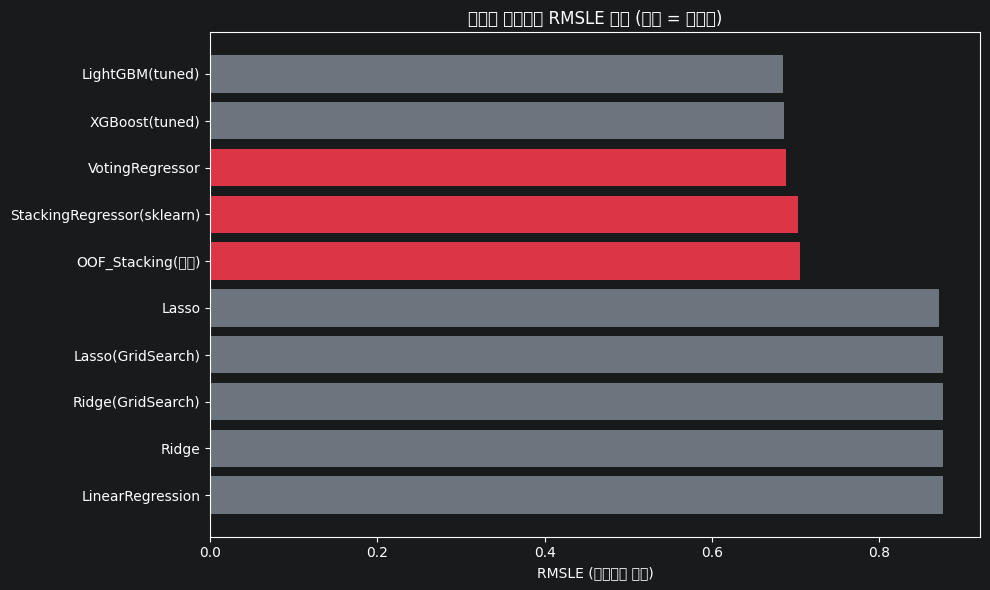

최고 성능 모델: LightGBM(tuned) (RMSLE=0.6856)


In [26]:
plt.figure(figsize=(10, 6))
ensemble_names = ["VotingRegressor", "StackingRegressor(sklearn)", "OOF_Stacking(수동)"]
colors = ["#dc3545" if n in ensemble_names else "#6c757d" for n in result_df["name"]]
plt.barh(result_df["name"][::-1], result_df["rmsle"][::-1], color=colors[::-1])
plt.xlabel("RMSLE (낮을수록 좋음)")
plt.title("모델별 테스트셋 RMSLE 비교 (빨강 = 앙상블)")
plt.tight_layout()
plt.show()

best_name = result_df.iloc[0]["name"]
print(f"최고 성능 모델: {best_name} (RMSLE={result_df.iloc[0]['rmsle']:.4f})")

### Voting vs Stacking(sklearn) vs OOF 수동 스태킹

| | VotingRegressor | StackingRegressor(sklearn) | OOF 수동 스태킹 |
|---|---|---|---|
| 동작 방식 | 베이스 모델 예측값을 (가중)평균 | 메타모델이 베이스 예측값을 다시 학습 | K-Fold로 직접 OOF 예측 생성 후 메타모델 학습 |
| 장점 | 단순하고 빠름, 과적합 위험 적음 | sklearn이 폴드 처리를 자동화 | 폴드 처리를 직접 제어, 메타데이터를 눈으로 검증 가능 |
| 단점 | 가중치를 사람이 직접 정해야 함 | 내부 동작이 블랙박스 | 코드가 더 길고 직접 구현해야 함 |
| 적합한 상황 | 데이터가 적거나 베이스 모델 성능이 비슷할 때 | 빠르게 스태킹을 적용하고 싶을 때 | 데이터 누수를 엄밀하게 막아야 하거나 폴드별 동작을 검증하고 싶을 때 |

sklearn `StackingRegressor`와 수동 OOF 스태킹은 원리상 거의 같은 일을 합니다. 다만 수동 구현은 `KFold(shuffle=False)`로 시계열 순서를 더 명시적으로 유지할 수 있고, 각 베이스 모델의 OOF 예측값을 중간에 직접 확인할 수 있다는 차이가 있습니다.

어느 쪽이 이 데이터에 더 좋은지는 바로 위 막대그래프와 표의 RMSLE 값으로 직접 확인하세요.

## 16. 최종 모델 선택 + 저장

테스트셋 RMSLE가 가장 낮은 모델을 최종 모델로 선택합니다.

주의: OOF 수동 스태킹은 `model_lookup`에 단일 객체로 넣을 수 없는 구조(메타모델 + 베이스 모델 3개 + 폴드 학습 절차)이므로, 만약 OOF 스태킹이 1위라면 sklearn StackingRegressor로 동일한 구성을 대체해서 저장합니다 (예측 시 동일한 동작을 하도록).

In [27]:
model_lookup = {
    "LinearRegression"          : lr_reg,
    "Ridge"                     : ridge_reg,
    "Lasso"                     : lasso_reg,
    "Ridge(GridSearch)"         : best_ridge,
    "Lasso(GridSearch)"         : best_lasso,
    "LightGBM(tuned)"           : lgbm_best,
    "XGBoost(tuned)"            : xgb_best,
    "VotingRegressor"           : voting_reg,
    "StackingRegressor(sklearn)": stacking_reg,
    # OOF_Stacking(수동)은 단일 객체가 아니므로 sklearn StackingRegressor로 대체합니다.
    "OOF_Stacking(수동)"         : stacking_reg,
}

final_name  = result_df.iloc[0]["name"]
final_model = model_lookup[final_name]

print(f"최종 선택 모델: {final_name}")
print(f"테스트셋 RMSLE: {result_df.iloc[0]['rmsle']:.4f}")
print(f"테스트셋 RMSE : {result_df.iloc[0]['rmse']:.3f}%p")
print(f"테스트셋 MAE  : {result_df.iloc[0]['mae']:.3f}%p")

최종 선택 모델: LightGBM(tuned)
테스트셋 RMSLE: 0.6856
테스트셋 RMSE : 1041.100%p
테스트셋 MAE  : 707.264%p


### pkl 저장

주의: 이 노트북은 로그 변환된 타깃(`y_train_log_full`)으로 모델을 학습했습니다. 따라서 `predict.py`에서 예측할 때도 모델 출력을 `np.expm1()`으로 역변환해야 합니다.

In [28]:
output_dir = Path("..") / "models_pkl"
output_dir.mkdir(exist_ok=True)

# predict.py가 예측 결과를 올바르게 해석하도록 메타 정보를 함께 저장한다.
#   target      : 무엇을 예측하는지 ("daily_count" = 일 이용대수)
#   log_target  : 로그 변환 학습 여부 (이 노트북은 log1p 학습 → True → predict.py에서 expm1)
#   feature_columns: 예측 시 입력 피처 순서(학습과 동일해야 함)
bundle = {
    "model"          : final_model,
    "target"         : "daily_count",
    "log_target"     : True,
    "feature_columns": FEATURE_COLUMNS,
    "model_name"     : final_name,
}

model_path = output_dir / "hangang_parking.pkl"
joblib.dump(bundle, model_path)

size_kb = model_path.stat().st_size / 1024
print(f"모델 저장 완료: {model_path.resolve()} ({size_kb:.1f} KB)")

모델 저장 완료: /Users/home/hangang_parking/models_pkl/hangang_parking.pkl (609.7 KB)


## 17. 저장된 모델 검증

로그 타깃으로 학습했으므로, 예측 후 반드시 `np.expm1()`으로 역변환해야 합니다.

In [29]:
loaded = joblib.load(model_path)
loaded_model    = loaded["model"]
is_log_target   = loaded["log_target"]
feature_columns = loaded["feature_columns"]

print(f"모델 로드 성공: {loaded['model_name']}")
print(f"예측 타깃: {loaded.get('target', 'daily_count')} / 로그 타깃 여부: {is_log_target}")

# 붐빔 4단계 (회전율 기준 고정 구간)
def grade(turnover):
    if turnover <= 100: return "여유"
    if turnover <= 200: return "보통"
    if turnover <= 350: return "붐빔"
    return "매우 붐빔"

# [lot_id, capacity, month, day_of_week, is_weekend, week_of_year, is_holiday]
test_cases = [
    ([1, 458, 8, 7, 1, 33, 1], "뚝섬 8월 일요일(공휴일)"),
    ([2, 532, 1, 2, 0, 2,  0], "여의도 1월 월요일"),
    ([6, 610, 5, 6, 1, 20, 0], "난지 5월 토요일"),
]

print()
print("[예측 테스트]")
for case, label in test_cases:
    X_input  = pd.DataFrame([case], columns=feature_columns)
    raw_pred = loaded_model.predict(X_input)[0]
    pred_cnt = np.expm1(raw_pred) if is_log_target else raw_pred   # 로그 역변환
    pred_cnt = max(0, int(round(float(pred_cnt))))                 # 예측 이용대수

    capacity = case[1]
    turnover = pred_cnt / capacity * 100
    remain   = f"여유 약 {capacity - pred_cnt}면" if turnover <= 100 else "잔여 추정 불가(회전)"
    print(f"  {label}: {pred_cnt:,}대 · 회전율 {turnover:.0f}% · {grade(turnover)} · {remain}")

모델 로드 성공: LightGBM(tuned)
예측 타깃: daily_count / 로그 타깃 여부: True

[예측 테스트]
  뚝섬 8월 일요일(공휴일): 1,195대 · 회전율 261% · 붐빔 · 잔여 추정 불가(회전)
  여의도 1월 월요일: 1,469대 · 회전율 276% · 붐빔 · 잔여 추정 불가(회전)
  난지 5월 토요일: 893대 · 회전율 146% · 보통 · 잔여 추정 불가(회전)


## 완료!

`predict.py`에서 이 pkl을 사용하려면 아래 부분을 수정해야 합니다.

```python
bundle = joblib.load("models_pkl/hangang_parking.pkl")
model         = bundle["model"]
is_log_target = bundle["log_target"]

raw_pred = model.predict(X)[0]
occupancy_pct = float(np.expm1(raw_pred)) if is_log_target else float(raw_pred)
occupancy_pct = max(0.0, min(100.0, occupancy_pct))
```

서버 재시작 후 Swagger에서 `POST /predict`로 확인하세요.

```bash
python main.py
```

In [30]:
# lsof -ti:5000 | xargs kill -9
# 기존에 떠 있는 MLflow UI를 종료

In [31]:
# mlflow ui --backend-store-uri sqlite:///mlflow.db
# 반드시 mlflow.db가 있는 폴더에서 실행